In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")

# Phần 1
print("5 dòng đầu: ", df.head())
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print("Kiểu dữ liệu từng cột:",df.dtypes)

numeric_cols = df.select_dtypes(include=[np.number]).columns

stats_dict = {}
for col in numeric_cols:
    stats_dict[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0],
        'Variance': df[col].var(),
        'Std Dev': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1 (25%)': df[col].quantile(0.25),
        'Q3 (75%)': df[col].quantile(0.75),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25)
    }

print("Biến số:")
df_stats = pd.DataFrame(stats_dict)
print(df_stats)

print("groupby:")
groupby_stats = df.groupby('species').agg(['mean', 'std'])
display(groupby_stats)


5 dòng đầu:     sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Số dòng: 150
Số cột: 5
Kiểu dữ liệu từng cột: sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
Biến số:
          sepal_length  sepal_width  petal_length  petal_width
Mean          5.843333     3.057333      3.758000     1.199333
Median        5.800000     3.000000      4.350000     1.300000
Mode          5.000000     3.000000      1.400000     0.200000
Variance      0.685694     0.189979      3.116278     0.581006
Std Dev       0.828066     0.435866      1.765298     0.762238
Min           4.300000     2.000000 

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

### Nhận xét Phần 1:

Nhóm loài setosa khác hai nhóm còn lại. petal_length & petal_width trung bình của nó nhỏ hơn nhiều. Std của petal_length setosa cũng nhỏ hơn 2 loài còn lại.

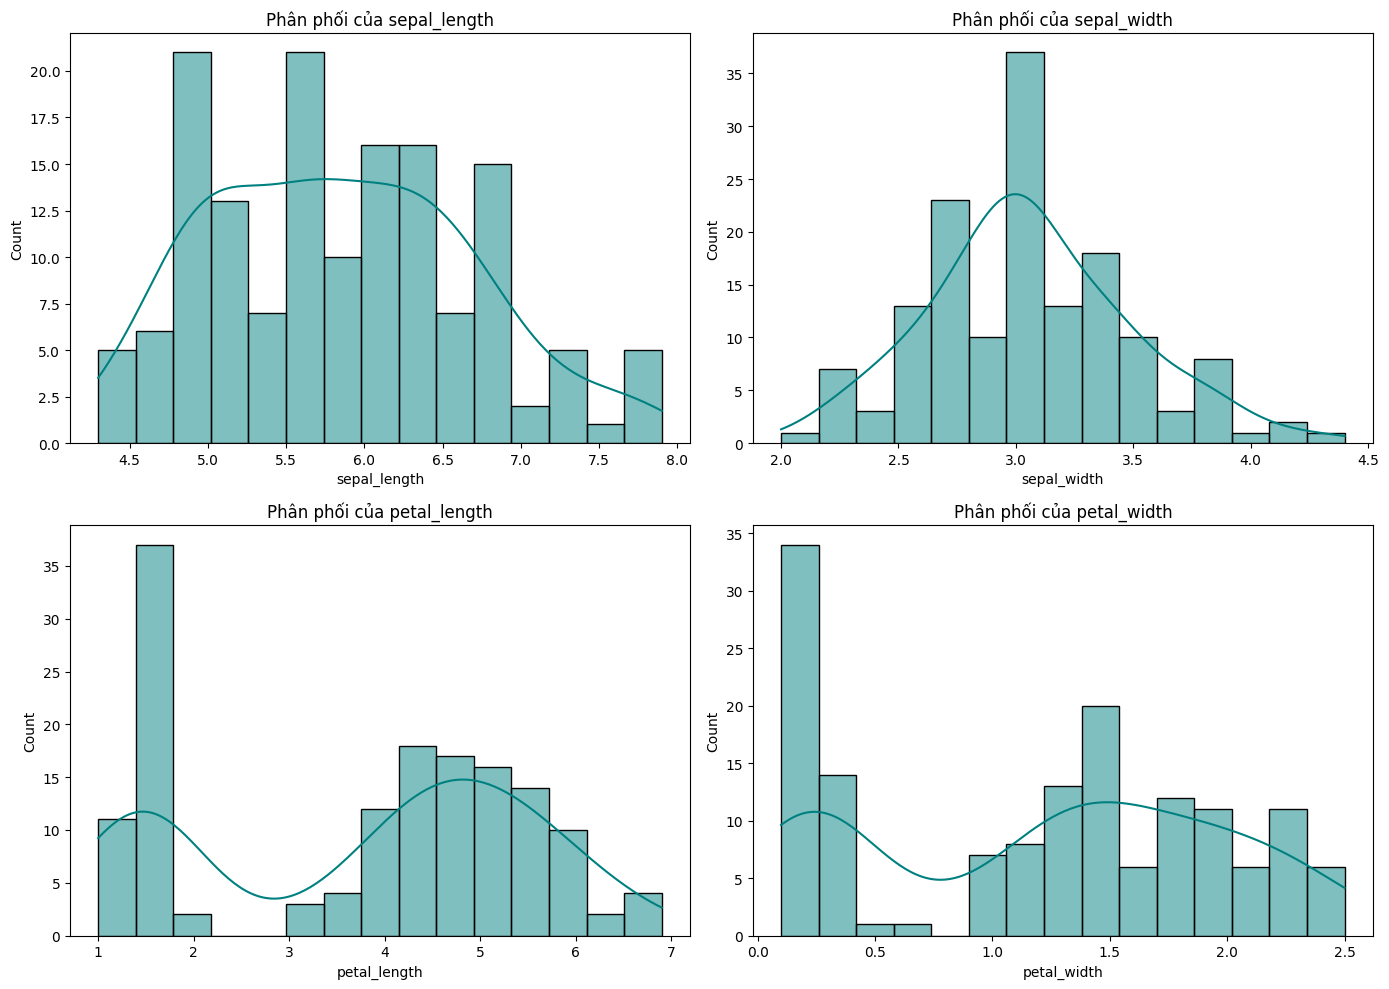

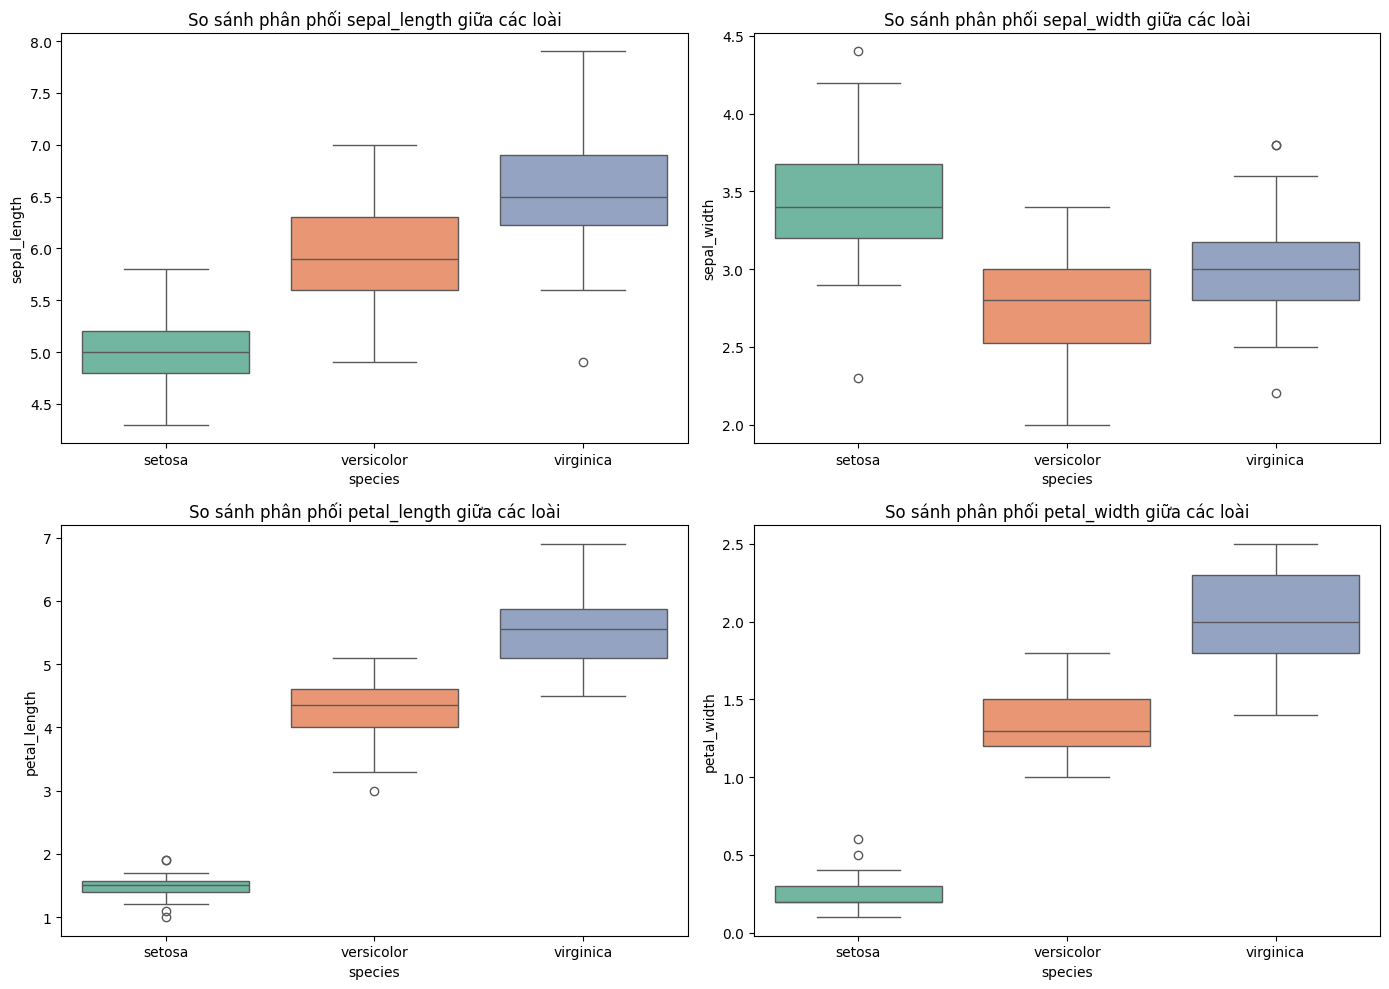

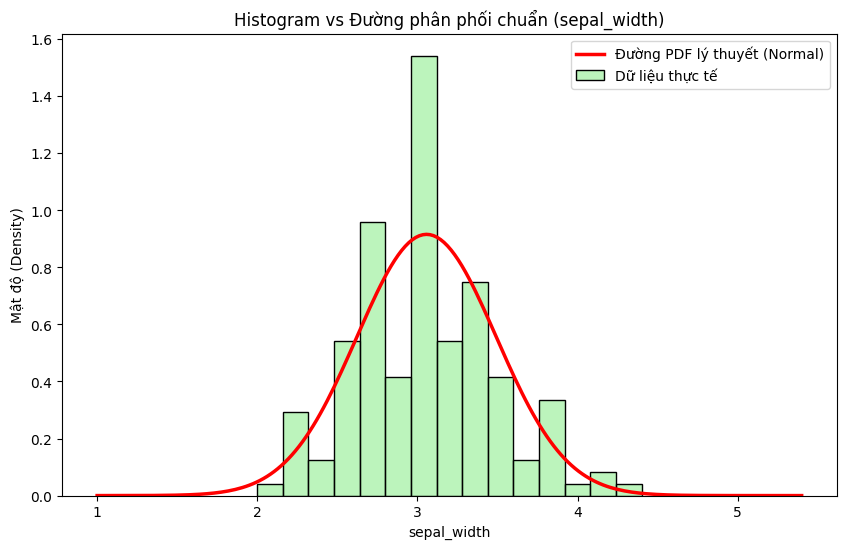

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")

# Phần 2
# Histogram + KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='teal', bins=15)
    axes[idx].set_title(f"Phân phối của {col}")
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[idx], hue='species', palette='Set2', legend=False)
    axes[idx].set_title(f"So sánh phân phối {col} giữa các loài")
plt.tight_layout()
plt.show()

# Mô phỏng
target_col = 'sepal_width'
mu = df[target_col].mean()
sigma = df[target_col].std()

# Sinh mẫu
simulated_sample = np.random.normal(mu, sigma, size=1000)

plt.figure(figsize=(10, 6))

# Histogram
sns.histplot(data=df, x=target_col, stat="density", color="lightgreen", alpha=0.6, label="Dữ liệu thực tế", bins=15)

# Tính PDF
x_axis = np.linspace(df[target_col].min() - 1, df[target_col].max() + 1, 200)
pdf_theoretical = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - mu) / sigma) ** 2)

# Vẽ PDF
plt.plot(x_axis, pdf_theoretical, color='red', linewidth=2.5, label="Đường PDF lý thuyết (Normal)")

plt.title(f"Histogram vs Đường phân phối chuẩn ({target_col})")
plt.xlabel(target_col)
plt.ylabel("Mật độ (Density)")
plt.legend()
plt.show()


### Nhận xét Phần 2:

Mô phỏng histogram khá khớp với đường PDF lý thuyết. Đặc biệt là phần nhô.

Covariance:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


Correlation:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


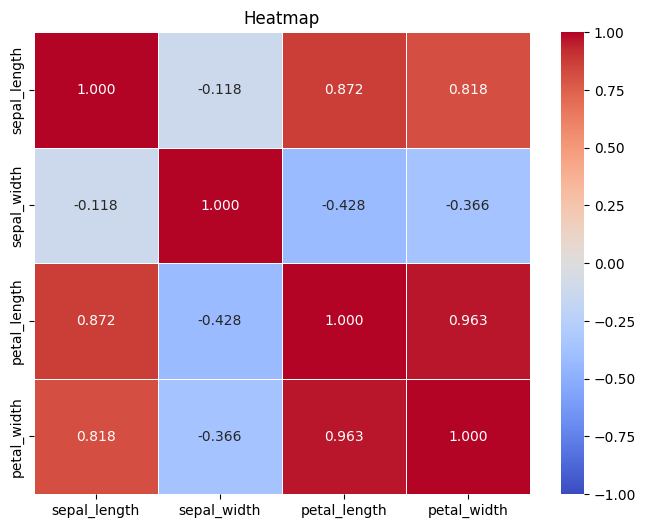

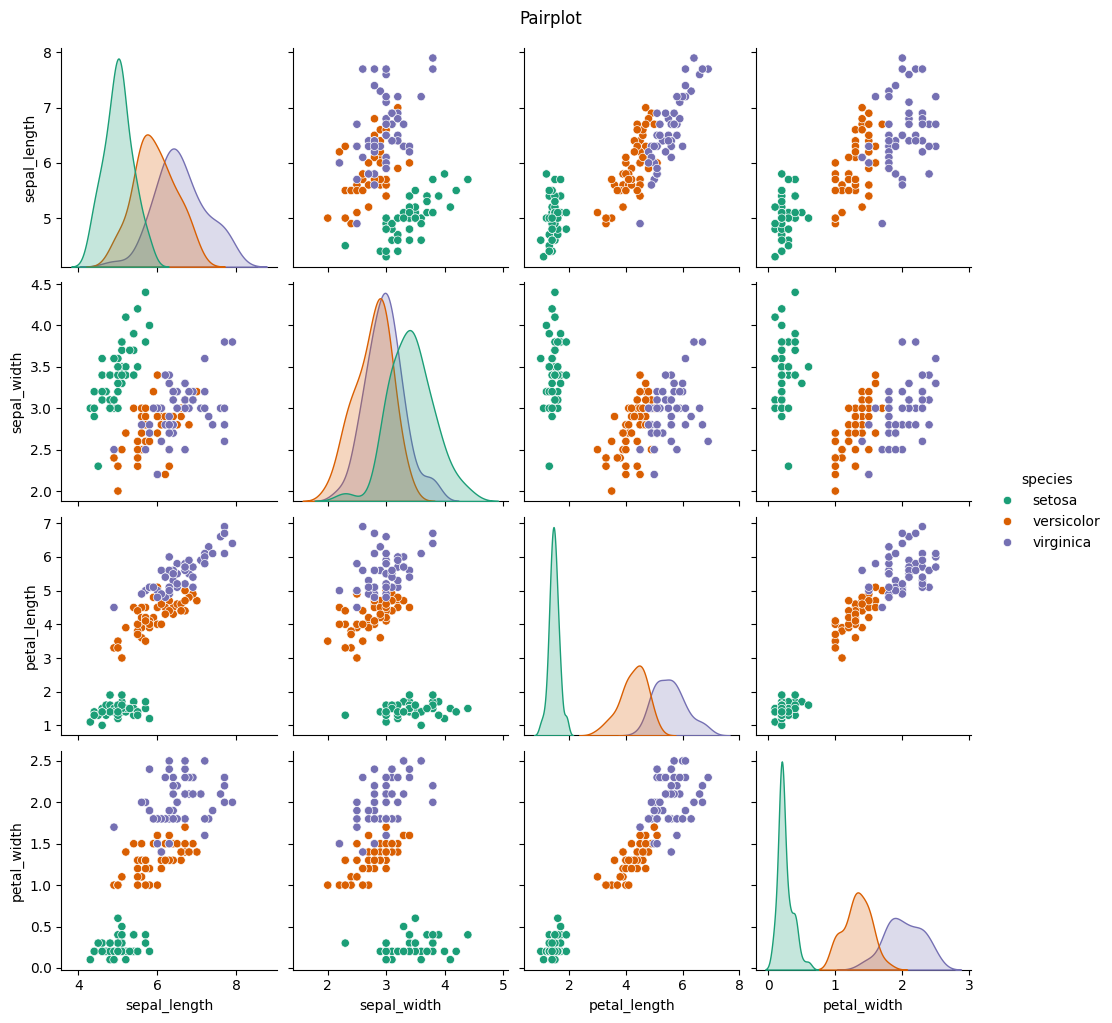

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Covariance:")
cov_matrix = df.cov(numeric_only=True)
display(cov_matrix)

print("Correlation:")
corr_matrix = df.corr(numeric_only=True)
display(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title("Heatmap")
plt.show()

# Pairplot
sns.pairplot(df, hue='species', palette='Dark2', diag_kind='kde')
plt.suptitle("Pairplot", y=1.02)
plt.show()

### Nhận xét Phần 3:
#### Heatmap
* Cặp biến tương quan mạnh nhất: petal_length và petal_width. Có hệ số 0.963.
* sepal_length cũng có tương quan cao với 2 biến khác nhau ở mức cao: petal_length(0.872), petal_width(0.818). Do đó có dấu hiệu đa cộng tuyến.

#### Pairplot
* Setosa (màu tím) thường nằm tách biệt rõ ràng so với versicolor (màu xanh) và virginica (màu cam) trên hầu hết các biểu đồ.


P(B|+) =  0.16666666666666669


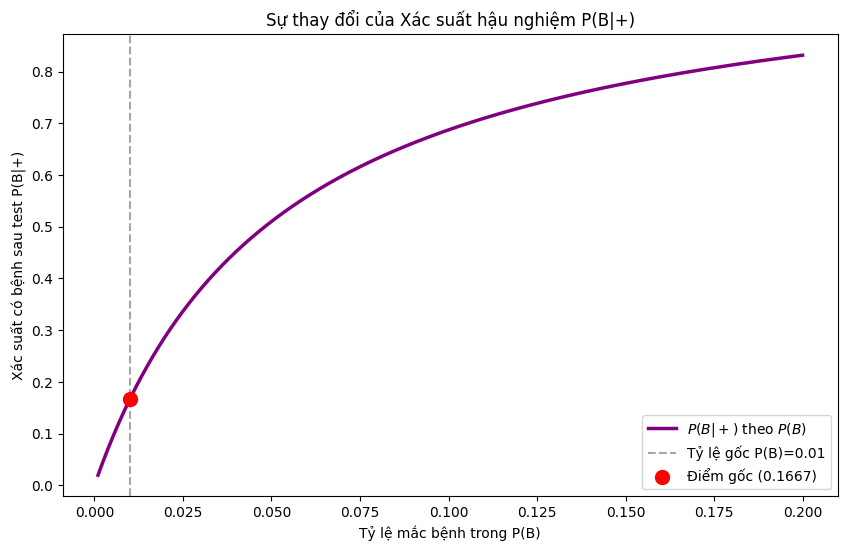

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Phần 4
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_notB = 0.05

# P(+)
P_not_B = 1 - P_B
P_pos = (P_pos_given_B * P_B) + (P_pos_given_notB * P_not_B)

# P(B|+)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos


print("P(B|+) = ", P_B_given_pos)

# P(B|+) khi P(B) chạy từ 0.001 đến 0.2
P_B_range = np.linspace(0.001, 0.2, 500)
P_B_given_pos_range = []

for pb in P_B_range:
    p_not_b = 1 - pb
    p_pos = (P_pos_given_B * pb) + (P_pos_given_notB * p_not_b)
    pb_given_pos = (P_pos_given_B * pb) / p_pos
    P_B_given_pos_range.append(pb_given_pos)

plt.figure(figsize=(10, 6))
plt.plot(P_B_range, P_B_given_pos_range, color='purple', linewidth=2.5, label=r"$P(B|+)$ theo $P(B)$")
plt.axvline(x=0.01, color='gray', linestyle='--', alpha=0.7, label='Tỷ lệ gốc P(B)=0.01')
plt.scatter([0.01], [P_B_given_pos], color='red', zorder=5, s=100, label=f"Điểm gốc ({P_B_given_pos:.4f})")

plt.title("Sự thay đổi của Xác suất hậu nghiệm P(B|+)")
plt.xlabel("Tỷ lệ mắc bệnh trong P(B)")
plt.ylabel("Xác suất có bệnh sau test P(B|+)")
plt.legend()
plt.show()


### Phản trực giác khi bệnh hiếm:
* Xác suất thực sự bị bệnh khi có kết quả dương tính chỉ có 16.67%.
* Vì bệnh cực kỳ hiếm (1\%) nên dù tỷ lệ dương tính giả rất nhỏ ($5\%$), số lượng người bệnh kết quả dương tính so với tổng thể sẽ rất nhỏ.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Bonus

class SimpleNaiveBayesSpamFilter:
    def __init__(self, alpha=1):
        self.alpha = alpha # Laplace smoothing để tránh xác suất bằng 0
        self.vocab = set()
        self.spam_word_counts = {}
        self.ham_word_counts = {}
        self.p_spam = 0.0
        self.p_ham = 0.0
        self.total_spam_words = 0
        self.total_ham_words = 0

    def clean_and_tokenize(self, text):
        return [w.strip('.,"?“”!\'()').lower() for w in text.split()]

    def fit(self, train_emails, train_labels):
        total_emails = len(train_labels)
        num_spam = sum(train_labels)
        num_ham = total_emails - num_spam

        # Tính xác suất tiền nghiệm
        self.p_spam = num_spam / total_emails
        self.p_ham = num_ham / total_emails

        # Thống kê tần suất từ vựng
        for email, label in zip(train_emails, train_labels):
            words = self.clean_and_tokenize(email)
            for word in words:
                self.vocab.add(word)
                if label == 1: # Spam
                    self.spam_word_counts[word] = self.spam_word_counts.get(word, 0) + 1
                    self.total_spam_words += 1
                else:          # Ham
                    self.ham_word_counts[word] = self.ham_word_counts.get(word, 0) + 1
                    self.total_ham_words += 1

    def predict_probability(self, email_text):
        words = self.clean_and_tokenize(email_text)

        # log-likelihood để tránh underflow khi nhân chuỗi xác suất nhỏ
        log_prob_spam = np.log(self.p_spam)
        log_prob_ham = np.log(self.p_ham)

        vocab_size = len(self.vocab)

        for word in words:
            # tính toán đk kèm Laplace Smoothing
            if word in self.vocab:
                count_spam = self.spam_word_counts.get(word, 0) + self.alpha
                count_ham = self.ham_word_counts.get(word, 0) + self.alpha

                log_prob_spam += np.log(count_spam / (self.total_spam_words + self.alpha * vocab_size))
                log_prob_ham += np.log(count_ham / (self.total_ham_words + self.alpha * vocab_size))

        prob_spam_unnormalized = np.exp(log_prob_spam)
        prob_ham_unnormalized = np.exp(log_prob_ham)

        p_spam_given_email = prob_spam_unnormalized / (prob_spam_unnormalized + prob_ham_unnormalized)
        return p_spam_given_email


# Tạo dữ liệu mẫu huấn luyện nhỏ (1: Spam, 0: Ham)
training_data = [
    ("Get free cash money now click this link to win financial freedom", 1),
    ("Urgent account update claim your free lottery cash prize today", 1),
    ("Please review the financial project report for our team meeting tomorrow", 0),
    ("Dear student, your course schedule and lecture note has been updated", 0),
    ("Click here to access free entry code and make easy money fast", 1),
    ("Can we meet for a cup of coffee this afternoon to discuss the plan", 0)
]

emails_train = [item[0] for item in training_data]
labels_train = [item[1] for item in training_data]

filter_nb = SimpleNaiveBayesSpamFilter(alpha=1)
filter_nb.fit(emails_train, labels_train)

test_emails = [
    "Hello, please check the attached project report file and send me feedback.",
    "WIN FREE CASH PRIZE NOW! CLICK THIS URGENT LINK TO CLAIM MONEY TODAY!!!",
    "Hey friend, are you free for a quick meeting or coffee this evening?"
]

for idx, mail in enumerate(test_emails):
    p_spam = filter_nb.predict_probability(mail)
    verdict = "SPAM" if p_spam > 0.5 else "HAM"
    print(f"Email {idx+1}: '{mail}'")
    print(f" => Xác suất là Spam: {p_spam*100:.2f}% -> Phân loại: {verdict}\n")

Email 1: 'Hello, please check the attached project report file and send me feedback.'
 => Xác suất là Spam: 4.44% -> Phân loại: HAM

Email 2: 'WIN FREE CASH PRIZE NOW! CLICK THIS URGENT LINK TO CLAIM MONEY TODAY!!!'
 => Xác suất là Spam: 100.00% -> Phân loại: SPAM

Email 3: 'Hey friend, are you free for a quick meeting or coffee this evening?'
 => Xác suất là Spam: 15.96% -> Phân loại: HAM

